In [ ]:
import gymnasium as gym
import numpy as np

In [ ]:
# Create FrozenLake environment
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)

In [ ]:
# Access the unwrapped environment to use the transition model
env = env.unwrapped
print(env)

<FrozenLakeEnv<FrozenLake-v1>>


In [ ]:
# Number of states and actions
n_states = env.observation_space.n
n_actions = env.action_space.n

In [ ]:
# Parameters
gamma = 0.99
theta = 1e-8

In [ ]:
# Random policy: each action has equal probability
policy = np.ones((n_states, n_actions)) / n_actions

In [ ]:
# -------------------------------------------------
# Policy Evaluation Function
# -------------------------------------------------
def policy_evaluation(policy, env, gamma=0.99, theta=1e-8):
    V = np.zeros(n_states)
    iterations = 0
    delta_history = []  # To store delta at each iteration

    while True:
        delta = 0

        for state in range(n_states):
            v = 0
            for action, action_prob in enumerate(policy[state]):
                for prob, next_state, reward, done in env.P[state][action]:
                    v += action_prob * prob * (reward + gamma * V[next_state] * (not done))

            delta = max(delta, abs(v - V[state]))
            V[state] = v

        iterations += 1
        delta_history.append(delta)

        if delta < theta:
            break

    return V, iterations, delta_history

In [ ]:
# Run policy evaluation
V, iterations, delta_history = policy_evaluation(policy, env, gamma, theta)

print("Name: Vikamuhan Reddy")
print("Register Number: 212223240181")
print("Number of iterations:", iterations)
print("\nState-Value Function:")
print(V)

print("Name: Vikamuhan Reddy")
print("Register Number: 212223240181")
print("\nState-Value Function as 4x4 Grid:")
print(np.round(V.reshape(4, 4), 4))

env.close()

Name: Vikamuhan Reddy
Register Number: 212223240181
Number of iterations: 54

State-Value Function:
[0.01235611 0.01042444 0.01933842 0.00947774 0.01478704 0.
 0.03889445 0.         0.03260247 0.08433764 0.13781085 0.
 0.         0.17034482 0.43357944 0.        ]
Name: Vikamuhan Reddy
Register Number: 212223240181

State-Value Function as 4x4 Grid:
[[0.0124 0.0104 0.0193 0.0095]
 [0.0148 0.     0.0389 0.    ]
 [0.0326 0.0843 0.1378 0.    ]
 [0.     0.1703 0.4336 0.    ]]


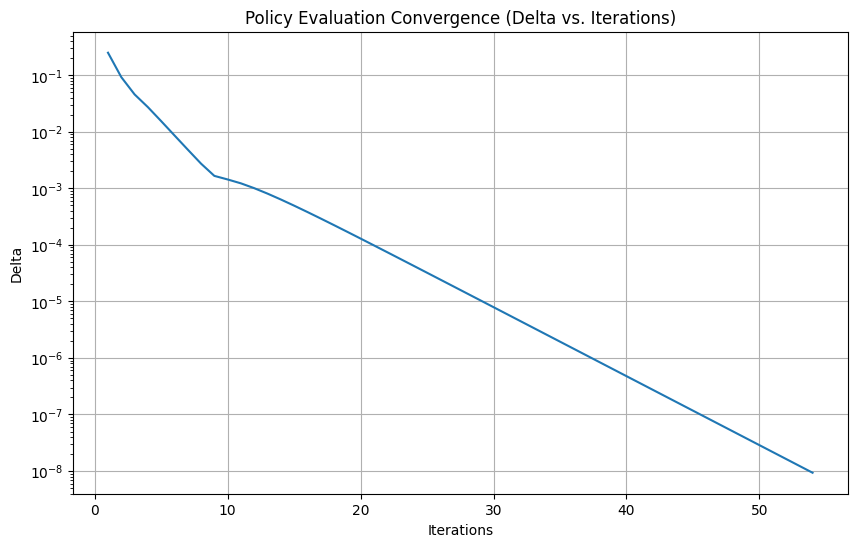

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, iterations + 1), delta_history)
plt.xlabel("Iterations")
plt.ylabel("Delta")
plt.title("Policy Evaluation Convergence (Delta vs. Iterations)")
plt.grid(True)
plt.semilogy() # Use a logarithmic scale for the y-axis to better visualize convergence
plt.show()